In [7]:
from pathlib import Path
import sys
import importlib
from collections import defaultdict
import numpy as np
import torch
import inspect
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import time
from tqdm import tqdm
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import src.utils
importlib.reload(src.utils)

import src.model
importlib.reload(src.model)

from src.utils import coco_paths, load_json
from src.model import load_rtdetr

In [8]:
images_dir, ann_file = coco_paths()
print(images_dir)
print(ann_file)
print(images_dir.exists(), ann_file.exists())

/home/semyon/Загрузки/rtdetr_cpu_project/data/images/val2017
/home/semyon/Загрузки/rtdetr_cpu_project/data/annotations/instances_val2017.json
True True


In [9]:
coco = load_json(ann_file)
print(coco.keys())
print("images:", len(coco["images"]))
print("annotations:", len(coco["annotations"]))
print("categories:", len(coco["categories"]))

dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])
images: 5000
annotations: 36781
categories: 80


In [10]:
model = load_rtdetr("rtdetr-l.pt")
model.info()

rt-detr-l summary: 449 layers, 32,970,476 parameters, 0 gradients, 108.3 GFLOPs


(449, 32970476, 0, 108.3437056)

In [11]:
sample_path = images_dir / coco["images"][0]["file_name"]
print(sample_path)
results = model(str(sample_path), verbose=False)
results

/home/semyon/Загрузки/rtdetr_cpu_project/data/images/val2017/000000397133.jpg


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

In [12]:
type(model.model)

ultralytics.nn.tasks.DetectionModel

In [13]:
for i, m in enumerate(model.model.model[:20]):
    print(i, type(m), getattr(m, "__class__", None).__name__)

0 <class 'ultralytics.nn.modules.block.HGStem'> HGStem
1 <class 'ultralytics.nn.modules.block.HGBlock'> HGBlock
2 <class 'ultralytics.nn.modules.conv.DWConv'> DWConv
3 <class 'ultralytics.nn.modules.block.HGBlock'> HGBlock
4 <class 'ultralytics.nn.modules.conv.DWConv'> DWConv
5 <class 'ultralytics.nn.modules.block.HGBlock'> HGBlock
6 <class 'ultralytics.nn.modules.block.HGBlock'> HGBlock
7 <class 'ultralytics.nn.modules.block.HGBlock'> HGBlock
8 <class 'ultralytics.nn.modules.conv.DWConv'> DWConv
9 <class 'ultralytics.nn.modules.block.HGBlock'> HGBlock
10 <class 'ultralytics.nn.modules.conv.Conv'> Conv
11 <class 'ultralytics.nn.modules.transformer.AIFI'> AIFI
12 <class 'ultralytics.nn.modules.conv.Conv'> Conv
13 <class 'torch.nn.modules.upsampling.Upsample'> Upsample
14 <class 'ultralytics.nn.modules.conv.Conv'> Conv
15 <class 'ultralytics.nn.modules.conv.Concat'> Concat
16 <class 'ultralytics.nn.modules.block.RepC3'> RepC3
17 <class 'ultralytics.nn.modules.conv.Conv'> Conv
18 <class '

In [14]:
print(model.model)

DetectionModel(
  (model): Sequential(
    (0): HGStem(
      (stem1): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (act): ReLU(inplace=True)
      )
      (stem2a): Conv(
        (conv): Conv2d(32, 16, kernel_size=(2, 2), stride=(1, 1))
        (act): ReLU(inplace=True)
      )
      (stem2b): Conv(
        (conv): Conv2d(16, 32, kernel_size=(2, 2), stride=(1, 1))
        (act): ReLU(inplace=True)
      )
      (stem3): Conv(
        (conv): Conv2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (act): ReLU(inplace=True)
      )
      (stem4): Conv(
        (conv): Conv2d(32, 48, kernel_size=(1, 1), stride=(1, 1))
        (act): ReLU(inplace=True)
      )
      (pool): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=True)
    )
    (1): HGBlock(
      (m): ModuleList(
        (0-5): 6 x Conv(
          (conv): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (act): ReLU(

In [15]:
decoder = model.model.model[28]
decoder

RTDETRDecoder(
  (input_proj): ModuleList(
    (0-2): 3 x Sequential(
      (0): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    )
  )
  (decoder): DeformableTransformerDecoder(
    (layers): ModuleList(
      (0-5): 6 x DeformableTransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (dropout1): Dropout(p=0.0, inplace=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (cross_attn): MSDeformAttn(
          (sampling_offsets): Linear(in_features=256, out_features=192, bias=True)
          (attention_weights): Linear(in_features=256, out_features=96, bias=True)
          (value_proj): Linear(in_features=256, out_features=256, bias=True)
          (output_proj): Linear(in_features=256, out_features=256, bias=True)
   

In [16]:
print(inspect.signature(decoder.forward))

(x: 'list[torch.Tensor]', batch: 'dict | None' = None) -> 'tuple | torch.Tensor'


In [17]:
print(inspect.getsource(decoder.forward))

    def forward(self, x: list[torch.Tensor], batch: dict | None = None) -> tuple | torch.Tensor:
        """Run the forward pass of the module, returning bounding box and classification scores for the input.

        Args:
            x (list[torch.Tensor]): List of feature maps from the backbone.
            batch (dict, optional): Batch information for training.

        Returns:
            outputs (tuple | torch.Tensor): During training, returns a tuple of bounding boxes, scores, and other
                metadata. During inference, returns a tensor of shape (bs, 300, 4+nc) containing bounding boxes and
                class scores.
        """
        from ultralytics.models.utils.ops import get_cdn_group

        # Input projection and embedding
        feats, shapes = self._get_encoder_input(x)

        # Prepare denoising training
        dn_embed, dn_bbox, attn_mask, dn_meta = get_cdn_group(
            batch,
            self.nc,
            self.num_queries,
            self

In [18]:
captured = {}

def decoder_hook(module, inputs, output):
    captured["decoder_output"] = output

handle = decoder.register_forward_hook(decoder_hook)

In [19]:
results = model(str(sample_path), verbose=False)
type(results), len(results)

(list, 1)

In [20]:
type(captured["decoder_output"])
len(captured["decoder_output"])

2

In [21]:
y, x = captured["decoder_output"]
dec_bboxes, dec_scores, enc_bboxes, enc_scores, dn_meta = x

In [22]:
print("y:", y.shape)
print("dec_bboxes:", dec_bboxes.shape)
print("dec_scores:", dec_scores.shape)
print("enc_bboxes:", enc_bboxes.shape)
print("enc_scores:", enc_scores.shape)
print("dn_meta:", dn_meta)

y: torch.Size([1, 300, 84])
dec_bboxes: torch.Size([1, 1, 300, 4])
dec_scores: torch.Size([1, 1, 300, 80])
enc_bboxes: torch.Size([1, 300, 4])
enc_scores: torch.Size([1, 300, 80])
dn_meta: None


In [23]:
handle.remove()

In [24]:
captured = {}

def save_output(name):
    def hook(module, inputs, output):
        captured[name] = output
    return hook

decoder = model.model.model[28]

h_score0 = decoder.dec_score_head[0].register_forward_hook(save_output("dec_score_0"))
h_bbox0 = decoder.dec_bbox_head[0].register_forward_hook(save_output("dec_bbox_0"))

In [25]:
results = model(str(sample_path), verbose=False)

In [26]:
print(type(captured.get("dec_score_0")))
print(type(captured.get("dec_bbox_0")))

if "dec_score_0" in captured:
    print("dec_score_0:", captured["dec_score_0"].shape)

if "dec_bbox_0" in captured:
    print("dec_bbox_0:", captured["dec_bbox_0"].shape)

<class 'NoneType'>
<class 'torch.Tensor'>
dec_bbox_0: torch.Size([1, 300, 4])


In [27]:
h_score0.remove()
h_bbox0.remove()

In [28]:
inner_decoder = decoder.decoder

print(inspect.signature(inner_decoder.forward))
print(inspect.getsource(inner_decoder.forward))

(embed: 'torch.Tensor', refer_bbox: 'torch.Tensor', feats: 'torch.Tensor', shapes: 'list', bbox_head: 'nn.Module', score_head: 'nn.Module', pos_mlp: 'nn.Module', attn_mask: 'torch.Tensor | None' = None, padding_mask: 'torch.Tensor | None' = None)
    def forward(
        self,
        embed: torch.Tensor,  # decoder embeddings
        refer_bbox: torch.Tensor,  # anchor
        feats: torch.Tensor,  # image features
        shapes: list,  # feature shapes
        bbox_head: nn.Module,
        score_head: nn.Module,
        pos_mlp: nn.Module,
        attn_mask: torch.Tensor | None = None,
        padding_mask: torch.Tensor | None = None,
    ):
        """Perform the forward pass through the entire decoder.

        Args:
            embed (torch.Tensor): Decoder embeddings.
            refer_bbox (torch.Tensor): Reference bounding boxes.
            feats (torch.Tensor): Image features.
            shapes (list): Feature shapes.
            bbox_head (nn.Module): Bounding box predicti

In [30]:
print("eval_idx =", inner_decoder.eval_idx)

eval_idx = 5


In [32]:
captured = {}

def decoder_hook(module, inputs, output):
    captured["decoder_output"] = output

handle = decoder.register_forward_hook(decoder_hook)

In [33]:
orig_eval_idx = inner_decoder.eval_idx
print("original eval_idx:", orig_eval_idx)

original eval_idx: 0


In [34]:
inner_decoder.eval_idx = 0

In [35]:
_ = model(str(sample_path), verbose=False)
print(captured.keys())

dict_keys(['decoder_output'])


In [36]:
y_early, x_early = captured["decoder_output"]
dec_bboxes_early, dec_scores_early, enc_bboxes_early, enc_scores_early, dn_meta_early = x_early

print("early dec_bboxes:", dec_bboxes_early.shape)
print("early dec_scores:", dec_scores_early.shape)

early dec_bboxes: torch.Size([1, 1, 300, 4])
early dec_scores: torch.Size([1, 1, 300, 80])


In [37]:
inner_decoder.eval_idx = orig_eval_idx
handle.remove()

In [38]:
inner_decoder.eval_idx = 5
print("current eval_idx:", inner_decoder.eval_idx)

current eval_idx: 5


In [39]:
def get_decoder_outputs(model, image_path, eval_idx):
    decoder = model.model.model[28]
    inner_decoder = decoder.decoder

    captured = {}

    def decoder_hook(module, inputs, output):
        captured["decoder_output"] = output

    handle = decoder.register_forward_hook(decoder_hook)

    old_idx = inner_decoder.eval_idx
    inner_decoder.eval_idx = eval_idx

    _ = model(str(image_path), verbose=False)

    inner_decoder.eval_idx = old_idx
    handle.remove()

    y, x = captured["decoder_output"]
    dec_bboxes, dec_scores, enc_bboxes, enc_scores, dn_meta = x

    return {
        "y": y,
        "dec_bboxes": dec_bboxes,
        "dec_scores": dec_scores,
        "enc_bboxes": enc_bboxes,
        "enc_scores": enc_scores,
    }


def query_scores_from_logits(logits):
    # logits: [1, 300, 80] or [1, 1, 300, 80]
    if logits.dim() == 4:
        logits = logits[0, 0]
    elif logits.dim() == 3:
        logits = logits[0]
    probs = logits.sigmoid()
    scores = probs.max(dim=-1).values
    return scores


def topk_indices(scores, k):
    return torch.topk(scores, k=k).indices.cpu()

In [40]:
outs_e1 = get_decoder_outputs(model, sample_path, eval_idx=0)
outs_l  = get_decoder_outputs(model, sample_path, eval_idx=5)

scores_e0 = query_scores_from_logits(outs_l["enc_scores"])      # E0
scores_e1 = query_scores_from_logits(outs_e1["dec_scores"])     # E1
scores_l  = query_scores_from_logits(outs_l["dec_scores"])      # L

print(scores_e0.shape, scores_e1.shape, scores_l.shape)
print(scores_e0[:10])

torch.Size([300]) torch.Size([300]) torch.Size([300])
tensor([0.9211, 0.7720, 0.7136, 0.6742, 0.6676, 0.6480, 0.6278, 0.6012, 0.6010, 0.4953])


In [41]:
def overlap_at_k(scores_a, scores_b, k):
    a = set(topk_indices(scores_a, k).tolist())
    b = set(topk_indices(scores_b, k).tolist())
    return len(a & b) / k

for k in [50, 100, 150]:
    print(
        f"k={k}",
        "E0 vs L:", round(overlap_at_k(scores_e0, scores_l, k), 3),
        "E1 vs L:", round(overlap_at_k(scores_e1, scores_l, k), 3),
    )

k=50 E0 vs L: 0.58 E1 vs L: 0.66
k=100 E0 vs L: 0.6 E1 vs L: 0.67
k=150 E0 vs L: 0.707 E1 vs L: 0.713


In [42]:
def get_image_annotations(coco_dict, image_id):
    anns = [a for a in coco_dict["annotations"] if a["image_id"] == image_id]
    return anns


def coco_bbox_to_xyxy(bbox):
    # COCO bbox = [x, y, w, h]
    x, y, w, h = bbox
    return [x, y, x + w, y + h]


def pred_cxcywh_to_xyxy(boxes, img_w, img_h):
    """
    boxes: torch.Tensor [N, 4] in normalized cx, cy, w, h
    returns: torch.Tensor [N, 4] in absolute xyxy
    """
    boxes = boxes.clone()
    cx = boxes[:, 0] * img_w
    cy = boxes[:, 1] * img_h
    w = boxes[:, 2] * img_w
    h = boxes[:, 3] * img_h

    x1 = cx - w / 2
    y1 = cy - h / 2
    x2 = cx + w / 2
    y2 = cy + h / 2

    return torch.stack([x1, y1, x2, y2], dim=1)


def box_iou_xyxy(boxes1, boxes2):
    """
    boxes1: [N, 4]
    boxes2: [M, 4]
    """
    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)

    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])   # [N, M, 2]
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])   # [N, M, 2]

    wh = (rb - lt).clamp(min=0)                           # [N, M, 2]
    inter = wh[:, :, 0] * wh[:, :, 1]                    # [N, M]

    union = area1[:, None] + area2 - inter
    return inter / union.clamp(min=1e-9)

In [43]:
def gt_coverage_at_k(pred_boxes, pred_scores, gt_boxes_xyxy, img_w, img_h, k, iou_thr=0.5):
    """
    pred_boxes: [1, 300, 4] or [1, 1, 300, 4]
    pred_scores: [300]
    gt_boxes_xyxy: [G, 4]
    """

    if pred_boxes.dim() == 4:
        pred_boxes = pred_boxes[0, 0]
    elif pred_boxes.dim() == 3:
        pred_boxes = pred_boxes[0]

    topk_idx = topk_indices(pred_scores, k)
    topk_boxes = pred_boxes[topk_idx]  # normalized cxcywh

    pred_xyxy = pred_cxcywh_to_xyxy(topk_boxes, img_w, img_h)

    if len(gt_boxes_xyxy) == 0:
        return None

    ious = box_iou_xyxy(pred_xyxy, gt_boxes_xyxy)   # [k, G]
    gt_covered = (ious.max(dim=0).values >= iou_thr).float()

    return {
        "covered": int(gt_covered.sum().item()),
        "total_gt": int(gt_boxes_xyxy.shape[0]),
        "coverage": float(gt_covered.mean().item()),
    }

In [44]:
img_info = coco["images"][0]
image_id = img_info["id"]
img_w = img_info["width"]
img_h = img_info["height"]

anns = get_image_annotations(coco, image_id)
gt_boxes = [coco_bbox_to_xyxy(a["bbox"]) for a in anns]
gt_boxes = torch.tensor(gt_boxes, dtype=torch.float32)

print("image_id:", image_id)
print("img size:", img_w, img_h)
print("num gt:", len(gt_boxes))

image_id: 397133
img size: 640 427
num gt: 19


In [45]:
boxes_e0 = outs_l["enc_bboxes"]        # E0
boxes_e1 = outs_e1["dec_bboxes"]       # E1
boxes_l  = outs_l["dec_bboxes"]        # L

for k in [50, 100, 150]:
    cov_e0 = gt_coverage_at_k(boxes_e0, scores_e0, gt_boxes, img_w, img_h, k)
    cov_e1 = gt_coverage_at_k(boxes_e1, scores_e1, gt_boxes, img_w, img_h, k)
    cov_l  = gt_coverage_at_k(boxes_l,  scores_l,  gt_boxes, img_w, img_h, k)

    print(f"k={k}")
    print("  E0:", cov_e0)
    print("  E1:", cov_e1)
    print("  L :", cov_l)

k=50
  E0: {'covered': 14, 'total_gt': 19, 'coverage': 0.7368420958518982}
  E1: {'covered': 14, 'total_gt': 19, 'coverage': 0.7368420958518982}
  L : {'covered': 14, 'total_gt': 19, 'coverage': 0.7368420958518982}
k=100
  E0: {'covered': 15, 'total_gt': 19, 'coverage': 0.7894737124443054}
  E1: {'covered': 15, 'total_gt': 19, 'coverage': 0.7894737124443054}
  L : {'covered': 15, 'total_gt': 19, 'coverage': 0.7894737124443054}
k=150
  E0: {'covered': 15, 'total_gt': 19, 'coverage': 0.7894737124443054}
  E1: {'covered': 15, 'total_gt': 19, 'coverage': 0.7894737124443054}
  L : {'covered': 15, 'total_gt': 19, 'coverage': 0.7894737124443054}


In [46]:
ann_index = defaultdict(list)
for ann in coco["annotations"]:
    ann_index[ann["image_id"]].append(ann)


def get_gt_boxes_for_image(img_info):
    anns = ann_index[img_info["id"]]
    gt_boxes = [coco_bbox_to_xyxy(a["bbox"]) for a in anns]
    if len(gt_boxes) == 0:
        return torch.zeros((0, 4), dtype=torch.float32)
    return torch.tensor(gt_boxes, dtype=torch.float32)


def evaluate_subset(model, images_subset, ks=(50, 100, 150)):
    stats = {k: {"ov_e0_l": [], "ov_e1_l": [],
                 "cov_e0": [], "cov_e1": [], "cov_l": []}
             for k in ks}

    for img_info in tqdm(images_subset):
        sample_path = images_dir / img_info["file_name"]
        img_w, img_h = img_info["width"], img_info["height"]
        gt_boxes = get_gt_boxes_for_image(img_info)

        # пропускаем пустые кадры
        if gt_boxes.shape[0] == 0:
            continue

        outs_e1 = get_decoder_outputs(model, sample_path, eval_idx=0)
        outs_l  = get_decoder_outputs(model, sample_path, eval_idx=5)

        scores_e0 = query_scores_from_logits(outs_l["enc_scores"])
        scores_e1 = query_scores_from_logits(outs_e1["dec_scores"])
        scores_l  = query_scores_from_logits(outs_l["dec_scores"])

        boxes_e0 = outs_l["enc_bboxes"]
        boxes_e1 = outs_e1["dec_bboxes"]
        boxes_l  = outs_l["dec_bboxes"]

        for k in ks:
            stats[k]["ov_e0_l"].append(overlap_at_k(scores_e0, scores_l, k))
            stats[k]["ov_e1_l"].append(overlap_at_k(scores_e1, scores_l, k))

            cov_e0 = gt_coverage_at_k(boxes_e0, scores_e0, gt_boxes, img_w, img_h, k)
            cov_e1 = gt_coverage_at_k(boxes_e1, scores_e1, gt_boxes, img_w, img_h, k)
            cov_l  = gt_coverage_at_k(boxes_l,  scores_l,  gt_boxes, img_w, img_h, k)

            stats[k]["cov_e0"].append(cov_e0["coverage"])
            stats[k]["cov_e1"].append(cov_e1["coverage"])
            stats[k]["cov_l"].append(cov_l["coverage"])

    summary = {}
    for k in ks:
        summary[k] = {
            "overlap_e0_l": float(np.mean(stats[k]["ov_e0_l"])) if stats[k]["ov_e0_l"] else None,
            "overlap_e1_l": float(np.mean(stats[k]["ov_e1_l"])) if stats[k]["ov_e1_l"] else None,
            "coverage_e0": float(np.mean(stats[k]["cov_e0"])) if stats[k]["cov_e0"] else None,
            "coverage_e1": float(np.mean(stats[k]["cov_e1"])) if stats[k]["cov_e1"] else None,
            "coverage_l":  float(np.mean(stats[k]["cov_l"]))  if stats[k]["cov_l"]  else None,
        }
    return summary

In [47]:
subset20 = coco["images"][:20]
summary20 = evaluate_subset(model, subset20, ks=(50, 100, 150))
summary20

100%|███████████████████████████████████████████| 20/20 [00:44<00:00,  2.22s/it]


{50: {'overlap_e0_l': 0.55,
  'overlap_e1_l': 0.603,
  'coverage_e0': 0.8920852750539779,
  'coverage_e1': 0.8827446192502976,
  'coverage_l': 0.9067678153514862},
 100: {'overlap_e0_l': 0.5615,
  'overlap_e1_l': 0.6220000000000001,
  'coverage_e0': 0.9058279663324356,
  'coverage_e1': 0.9054358094930649,
  'coverage_l': 0.9341598629951477},
 150: {'overlap_e0_l': 0.627,
  'overlap_e1_l': 0.6676666666666666,
  'coverage_e0': 0.9179708242416382,
  'coverage_e1': 0.9236897766590119,
  'coverage_l': 0.9360829412937164}}

In [48]:
def density_bucket(num_gt):
    if num_gt <= 5:
        return "sparse"
    elif num_gt <= 15:
        return "medium"
    else:
        return "crowded"


def evaluate_subset_by_density(model, images_subset, ks=(50, 100, 150)):
    stats = {
        bucket: {
            k: {
                "ov_e0_l": [], "ov_e1_l": [],
                "cov_e0": [], "cov_e1": [], "cov_l": []
            } for k in ks
        }
        for bucket in ["sparse", "medium", "crowded"]
    }

    for img_info in tqdm(images_subset):
        sample_path = images_dir / img_info["file_name"]
        img_w, img_h = img_info["width"], img_info["height"]
        gt_boxes = get_gt_boxes_for_image(img_info)

        if gt_boxes.shape[0] == 0:
            continue

        bucket = density_bucket(gt_boxes.shape[0])

        outs_e1 = get_decoder_outputs(model, sample_path, eval_idx=0)
        outs_l  = get_decoder_outputs(model, sample_path, eval_idx=5)

        scores_e0 = query_scores_from_logits(outs_l["enc_scores"])
        scores_e1 = query_scores_from_logits(outs_e1["dec_scores"])
        scores_l  = query_scores_from_logits(outs_l["dec_scores"])

        boxes_e0 = outs_l["enc_bboxes"]
        boxes_e1 = outs_e1["dec_bboxes"]
        boxes_l  = outs_l["dec_bboxes"]

        for k in ks:
            stats[bucket][k]["ov_e0_l"].append(overlap_at_k(scores_e0, scores_l, k))
            stats[bucket][k]["ov_e1_l"].append(overlap_at_k(scores_e1, scores_l, k))

            cov_e0 = gt_coverage_at_k(boxes_e0, scores_e0, gt_boxes, img_w, img_h, k)
            cov_e1 = gt_coverage_at_k(boxes_e1, scores_e1, gt_boxes, img_w, img_h, k)
            cov_l  = gt_coverage_at_k(boxes_l,  scores_l,  gt_boxes, img_w, img_h, k)

            stats[bucket][k]["cov_e0"].append(cov_e0["coverage"])
            stats[bucket][k]["cov_e1"].append(cov_e1["coverage"])
            stats[bucket][k]["cov_l"].append(cov_l["coverage"])

    summary = {}
    for bucket in ["sparse", "medium", "crowded"]:
        summary[bucket] = {}
        for k in ks:
            d = stats[bucket][k]
            summary[bucket][k] = {
                "n_images": len(d["ov_e0_l"]),
                "overlap_e0_l": float(np.mean(d["ov_e0_l"])) if d["ov_e0_l"] else None,
                "overlap_e1_l": float(np.mean(d["ov_e1_l"])) if d["ov_e1_l"] else None,
                "coverage_e0": float(np.mean(d["cov_e0"])) if d["cov_e0"] else None,
                "coverage_e1": float(np.mean(d["cov_e1"])) if d["cov_e1"] else None,
                "coverage_l":  float(np.mean(d["cov_l"]))  if d["cov_l"]  else None,
            }
    return summary

In [49]:
subset100 = coco["images"][:100]
summary100_density = evaluate_subset_by_density(model, subset100, ks=(50, 100, 150))
summary100_density

100%|█████████████████████████████████████████| 100/100 [03:31<00:00,  2.12s/it]


{'sparse': {50: {'n_images': 57,
   'overlap_e0_l': 0.44842105263157894,
   'overlap_e1_l': 0.5056140350877193,
   'coverage_e0': 0.9675438613222357,
   'coverage_e1': 0.9719298262345163,
   'coverage_l': 0.98713450369082},
  100: {'n_images': 57,
   'overlap_e0_l': 0.5036842105263158,
   'overlap_e1_l': 0.5615789473684211,
   'coverage_e0': 0.9827485387785393,
   'coverage_e1': 0.9894736848379436,
   'coverage_l': 0.992982456558629},
  150: {'n_images': 57,
   'overlap_e0_l': 0.5870175438596491,
   'overlap_e1_l': 0.6374269005847952,
   'coverage_e0': 0.992982456558629,
   'coverage_e1': 0.9894736848379436,
   'coverage_l': 0.992982456558629}},
 'medium': {50: {'n_images': 30,
   'overlap_e0_l': 0.5660000000000001,
   'overlap_e1_l': 0.6153333333333333,
   'coverage_e0': 0.8921739389499028,
   'coverage_e1': 0.8878241231044134,
   'coverage_l': 0.9030866374572118},
  100: {'n_images': 30,
   'overlap_e0_l': 0.5749999999999998,
   'overlap_e1_l': 0.6253333333333333,
   'coverage_e0': 0

In [50]:
decoder = model.model.model[28]
inner_decoder = decoder.decoder


def run_model_with_eval_idx(model, image_path, eval_idx):
    old_idx = inner_decoder.eval_idx
    inner_decoder.eval_idx = eval_idx
    _ = model(str(image_path), verbose=False)
    inner_decoder.eval_idx = old_idx


def benchmark_eval_idx(model, images_subset, eval_idx, warmup=3):
    # warmup
    for img_info in images_subset[:warmup]:
        sample_path = images_dir / img_info["file_name"]
        run_model_with_eval_idx(model, sample_path, eval_idx)

    times = []
    for img_info in tqdm(images_subset, desc=f"eval_idx={eval_idx}"):
        sample_path = images_dir / img_info["file_name"]

        t0 = time.perf_counter()
        run_model_with_eval_idx(model, sample_path, eval_idx)
        t1 = time.perf_counter()

        times.append((t1 - t0) * 1000.0)  # ms

    return {
        "eval_idx": eval_idx,
        "n": len(times),
        "mean_ms": float(np.mean(times)),
        "median_ms": float(np.median(times)),
        "std_ms": float(np.std(times)),
        "min_ms": float(np.min(times)),
        "max_ms": float(np.max(times)),
        "all_ms": times,
    }

In [51]:
subset30 = coco["images"][:30]

In [52]:
lat_e1 = benchmark_eval_idx(model, subset30, eval_idx=0, warmup=3)
lat_l  = benchmark_eval_idx(model, subset30, eval_idx=5, warmup=3)

lat_e1, lat_l

eval_idx=5: 100%|███████████████████████████████| 30/30 [00:34<00:00,  1.14s/it]


({'eval_idx': 0,
  'n': 30,
  'mean_ms': 997.8273813332029,
  'median_ms': 934.1782070005138,
  'std_ms': 128.43792092239877,
  'min_ms': 868.2653039995785,
  'max_ms': 1433.1097040012537,
  'all_ms': [1125.6662310006504,
   1005.170176998945,
   995.5306529991503,
   1015.0629489999119,
   1008.7559450003027,
   1127.13204299871,
   911.002066999572,
   918.605471999399,
   1155.0039409994497,
   1135.6050379999942,
   965.0964659995225,
   1188.0604879988823,
   1053.3523989997775,
   887.5283540000964,
   934.6900529999402,
   886.687582000377,
   915.1420689995575,
   868.2653039995785,
   904.1168090006977,
   992.6487370012183,
   919.2298109992407,
   902.633206000246,
   895.9050079993176,
   916.395325000849,
   899.0088629998354,
   933.6663610010874,
   1223.9516959998582,
   1433.1097040012537,
   911.1494709995895,
   906.6492179990746]},
 {'eval_idx': 5,
  'n': 30,
  'mean_ms': 1136.682422100057,
  'median_ms': 1092.557192499953,
  'std_ms': 109.92873054031188,
  'min_ms'

In [53]:
def print_latency_summary(name, d):
    print(name)
    print(f"  n       : {d['n']}")
    print(f"  mean_ms : {d['mean_ms']:.2f}")
    print(f"  median  : {d['median_ms']:.2f}")
    print(f"  std_ms  : {d['std_ms']:.2f}")
    print(f"  min_ms  : {d['min_ms']:.2f}")
    print(f"  max_ms  : {d['max_ms']:.2f}")

print_latency_summary("E1 (eval_idx=0)", lat_e1)
print_latency_summary("L  (eval_idx=5)", lat_l)

speedup_mean = lat_l["mean_ms"] / lat_e1["mean_ms"]
speedup_median = lat_l["median_ms"] / lat_e1["median_ms"]

print(f"\nSpeedup by mean   : {speedup_mean:.3f}x")
print(f"Speedup by median : {speedup_median:.3f}x")
print(f"Saved mean ms     : {lat_l['mean_ms'] - lat_e1['mean_ms']:.2f}")
print(f"Saved median ms   : {lat_l['median_ms'] - lat_e1['median_ms']:.2f}")

E1 (eval_idx=0)
  n       : 30
  mean_ms : 997.83
  median  : 934.18
  std_ms  : 128.44
  min_ms  : 868.27
  max_ms  : 1433.11
L  (eval_idx=5)
  n       : 30
  mean_ms : 1136.68
  median  : 1092.56
  std_ms  : 109.93
  min_ms  : 1038.52
  max_ms  : 1539.86

Speedup by mean   : 1.139x
Speedup by median : 1.170x
Saved mean ms     : 138.86
Saved median ms   : 158.38


In [55]:
coco_api = COCO(str(ann_file))

CLASS_NAMES = results[0].names
name_to_catid = {c["name"]: c["id"] for c in coco["categories"]}
label_to_catid = {i: name_to_catid[CLASS_NAMES[i]] for i in range(80)}

label_to_catid

loading annotations into memory...
Done (t=1.05s)
creating index...
index created!


{0: 1,
 1: 2,
 2: 3,
 3: 4,
 4: 5,
 5: 6,
 6: 7,
 7: 8,
 8: 9,
 9: 10,
 10: 11,
 11: 13,
 12: 14,
 13: 15,
 14: 16,
 15: 17,
 16: 18,
 17: 19,
 18: 20,
 19: 21,
 20: 22,
 21: 23,
 22: 24,
 23: 25,
 24: 27,
 25: 28,
 26: 31,
 27: 32,
 28: 33,
 29: 34,
 30: 35,
 31: 36,
 32: 37,
 33: 38,
 34: 39,
 35: 40,
 36: 41,
 37: 42,
 38: 43,
 39: 44,
 40: 46,
 41: 47,
 42: 48,
 43: 49,
 44: 50,
 45: 51,
 46: 52,
 47: 53,
 48: 54,
 49: 55,
 50: 56,
 51: 57,
 52: 58,
 53: 59,
 54: 60,
 55: 61,
 56: 62,
 57: 63,
 58: 64,
 59: 65,
 60: 67,
 61: 70,
 62: 72,
 63: 73,
 64: 74,
 65: 75,
 66: 76,
 67: 77,
 68: 78,
 69: 79,
 70: 80,
 71: 81,
 72: 82,
 73: 84,
 74: 85,
 75: 86,
 76: 87,
 77: 88,
 78: 89,
 79: 90}

In [56]:
def y_to_coco_predictions(y, img_info, k=None):
    """
    y: [1, 300, 84] or [300, 84]
    4 bbox + 80 class probs
    """
    if y.dim() == 3:
        y = y[0]
    y = y.cpu()

    boxes = y[:, :4]      # normalized cxcywh
    probs = y[:, 4:]      # already sigmoid probs

    scores, labels = probs.max(dim=1)

    if k is not None:
        idx = torch.topk(scores, k=k).indices
        boxes = boxes[idx]
        scores = scores[idx]
        labels = labels[idx]

    pred_xyxy = pred_cxcywh_to_xyxy(boxes, img_info["width"], img_info["height"])

    x1 = pred_xyxy[:, 0]
    y1 = pred_xyxy[:, 1]
    x2 = pred_xyxy[:, 2]
    y2 = pred_xyxy[:, 3]

    pred_xywh = torch.stack([x1, y1, x2 - x1, y2 - y1], dim=1)

    preds = []
    for box, score, label in zip(pred_xywh.tolist(), scores.tolist(), labels.tolist()):
        preds.append({
            "image_id": img_info["id"],
            "category_id": label_to_catid[int(label)],
            "bbox": [float(v) for v in box],
            "score": float(score),
        })
    return preds

In [57]:
def evaluate_coco_subset(model, images_subset, eval_idx, k=None):
    preds = []

    for img_info in tqdm(images_subset, desc=f"eval_idx={eval_idx}, k={k}"):
        sample_path = images_dir / img_info["file_name"]
        outs = get_decoder_outputs(model, sample_path, eval_idx=eval_idx)
        preds.extend(y_to_coco_predictions(outs["y"], img_info, k=k))

    coco_dt = coco_api.loadRes(preds)
    evaluator = COCOeval(coco_api, coco_dt, "bbox")
    evaluator.params.imgIds = [img["id"] for img in images_subset]

    evaluator.evaluate()
    evaluator.accumulate()
    evaluator.summarize()

    return {
        "AP": float(evaluator.stats[0]),
        "AP50": float(evaluator.stats[1]),
        "AP75": float(evaluator.stats[2]),
        "APS": float(evaluator.stats[3]),
        "APM": float(evaluator.stats[4]),
        "APL": float(evaluator.stats[5]),
    }

In [58]:
subset30 = coco["images"][:30]

metrics_l_full   = evaluate_coco_subset(model, subset30, eval_idx=5, k=None)
metrics_e1_full  = evaluate_coco_subset(model, subset30, eval_idx=0, k=None)
metrics_l_k100   = evaluate_coco_subset(model, subset30, eval_idx=5, k=100)
metrics_e1_k100  = evaluate_coco_subset(model, subset30, eval_idx=0, k=100)

metrics_l_full, metrics_e1_full, metrics_l_k100, metrics_e1_k100

eval_idx=5, k=None: 100%|███████████████████████| 30/30 [00:37<00:00,  1.26s/it]


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.35s).
Accumulating evaluation results...
DONE (t=0.16s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.546
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.709
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.610
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.379
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.728
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.861
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.411
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.616
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.658
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

eval_idx=0, k=None: 100%|███████████████████████| 30/30 [00:29<00:00,  1.01it/s]


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.37s).
Accumulating evaluation results...
DONE (t=0.16s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.508
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.654
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.573
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.361
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.687
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.827
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.392
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.593
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.632
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

eval_idx=5, k=100: 100%|████████████████████████| 30/30 [00:34<00:00,  1.15s/it]


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.20s).
Accumulating evaluation results...
DONE (t=0.16s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.545
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.709
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.609
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.378
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.728
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.859
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.408
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.611
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.647
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

eval_idx=0, k=100: 100%|████████████████████████| 30/30 [00:29<00:00,  1.01it/s]


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.21s).
Accumulating evaluation results...
DONE (t=0.14s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.488
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.624
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.556
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.362
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.654
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.821
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.370
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.559
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.587
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

({'AP': 0.5460094840589664,
  'AP50': 0.709314513637395,
  'AP75': 0.6101047756045854,
  'APS': 0.3785838682563516,
  'APM': 0.7284967356537561,
  'APL': 0.8611174953388837},
 {'AP': 0.5080236780327052,
  'AP50': 0.6542092461570976,
  'AP75': 0.5734291538785218,
  'APS': 0.3613478491259884,
  'APM': 0.6866180488488085,
  'APL': 0.8268513714314094},
 {'AP': 0.545005633262247,
  'AP50': 0.7086878817952403,
  'AP75': 0.6092236797655038,
  'APS': 0.3782760046925376,
  'APM': 0.7275292801712383,
  'APL': 0.8590772913184815},
 {'AP': 0.4879409131446664,
  'AP50': 0.623632249163406,
  'AP75': 0.556071100554746,
  'APS': 0.3615684543060846,
  'APM': 0.6543005771171425,
  'APL': 0.8211278261039037})

In [60]:
df30 = pd.DataFrame([
    {"mode": "L-full",  **metrics_l_full},
    {"mode": "E1-full", **metrics_e1_full},
    {"mode": "L-k100",  **metrics_l_k100},
    {"mode": "E1-k100", **metrics_e1_k100},
])

df30

,mode,AP,AP50,AP75,APS,APM,APL
0,L-full,0.546009,0.709315,0.610105,0.378584,0.728497,0.861117
1,E1-full,0.508024,0.654209,0.573429,0.361348,0.686618,0.826851
2,L-k100,0.545006,0.708688,0.609224,0.378276,0.727529,0.859077
3,E1-k100,0.487941,0.623632,0.556071,0.361568,0.654301,0.821128


In [61]:
subset100 = coco["images"][:100]

modes = [
    ("L-full",  5, None),
    ("E1-full", 0, None),
    ("L-k50",   5, 50),
    ("E1-k50",  0, 50),
    ("L-k75",   5, 75),
    ("E1-k75",  0, 75),
]

all_metrics = []

for mode_name, eval_idx, k in modes:
    print(f"\n=== {mode_name} ===")
    metrics = evaluate_coco_subset(model, subset100, eval_idx=eval_idx, k=k)
    all_metrics.append({
        "mode": mode_name,
        "eval_idx": eval_idx,
        "k": k if k is not None else "full",
        **metrics
    })


=== L-full ===


eval_idx=5, k=None: 100%|█████████████████████| 100/100 [02:05<00:00,  1.25s/it]


Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.99s).
Accumulating evaluation results...
DONE (t=0.37s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.597
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.757
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.656
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.424
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.672
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.769
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.466
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.693
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.737
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

eval_idx=0, k=None: 100%|█████████████████████| 100/100 [02:04<00:00,  1.24s/it]


Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.13s).
Accumulating evaluation results...
DONE (t=0.35s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.557
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.711
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.616
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.394
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.627
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.752
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.431
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.682
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.736
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

...

Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.78s).
Accumulating evaluation results...
DONE (t=0.26s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.541
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.683
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.603
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.368
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.610
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.745
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.413
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.635
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.663
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

eval_idx=5, k=75: 100%|███████████████████████| 100/100 [02:10<00:00,  1.31s/it]


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.50s).
Accumulating evaluation results...
DONE (t=0.31s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.594
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.752
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.652
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.415
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.671
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.767
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.464
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.680
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.716
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

eval_idx=0, k=75: 100%|███████████████████████| 100/100 [02:02<00:00,  1.23s/it]


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.47s).
Accumulating evaluation results...
DONE (t=0.30s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.544
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.688
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.608
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.386
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.613
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.749
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.415
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.649
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.684
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

In [62]:
df100 = pd.DataFrame(all_metrics)
df100

,mode,eval_idx,k,AP,AP50,AP75,APS,APM,APL
0,L-full,5,full,0.597292,0.757216,0.656210,0.423883,0.672331,0.768565
1,E1-full,0,full,0.557153,0.710557,0.615641,0.394241,0.626801,0.751734
2,L-k50,5,50,0.592073,0.751244,0.650362,0.397441,0.667476,0.766581
3,E1-k50,0,50,0.540721,0.682878,0.603001,0.367520,0.610413,0.744911
4,L-k75,5,75,0.594011,0.752185,0.652392,0.414728,0.671374,0.767495
5,E1-k75,0,75,0.544006,0.687778,0.607524,0.385826,0.613096,0.748867


In [63]:
base_ap = df100.loc[df100["mode"] == "L-full", "AP"].iloc[0]
base_ap50 = df100.loc[df100["mode"] == "L-full", "AP50"].iloc[0]

df100["AP_drop_vs_Lfull"] = base_ap - df100["AP"]
df100["AP50_drop_vs_Lfull"] = base_ap50 - df100["AP50"]

df100

,mode,eval_idx,k,AP,AP50,AP75,APS,APM,APL,AP_drop_vs_Lfull,AP50_drop_vs_Lfull
0,L-full,5,full,0.597292,0.757216,0.656210,0.423883,0.672331,0.768565,0.000000,0.000000
1,E1-full,0,full,0.557153,0.710557,0.615641,0.394241,0.626801,0.751734,0.040138,0.046659
2,L-k50,5,50,0.592073,0.751244,0.650362,0.397441,0.667476,0.766581,0.005219,0.005971
3,E1-k50,0,50,0.540721,0.682878,0.603001,0.367520,0.610413,0.744911,0.056571,0.074338
4,L-k75,5,75,0.594011,0.752185,0.652392,0.414728,0.671374,0.767495,0.003281,0.005031
5,E1-k75,0,75,0.544006,0.687778,0.607524,0.385826,0.613096,0.748867,0.053286,0.069438


In [64]:
latency_map = {
    "E1-full": lat_e1["mean_ms"],
    "L-full": lat_l["mean_ms"],
}

df100["mean_latency_ms"] = df100["mode"].map(latency_map)
df100

,mode,eval_idx,k,AP,AP50,AP75,APS,APM,APL,AP_drop_vs_Lfull,AP50_drop_vs_Lfull,mean_latency_ms
0,L-full,5,full,0.597292,0.757216,0.656210,0.423883,0.672331,0.768565,0.000000,0.000000,1136.682422
1,E1-full,0,full,0.557153,0.710557,0.615641,0.394241,0.626801,0.751734,0.040138,0.046659,997.827381
2,L-k50,5,50,0.592073,0.751244,0.650362,0.397441,0.667476,0.766581,0.005219,0.005971,NaN
3,E1-k50,0,50,0.540721,0.682878,0.603001,0.367520,0.610413,0.744911,0.056571,0.074338,NaN
4,L-k75,5,75,0.594011,0.752185,0.652392,0.414728,0.671374,0.767495,0.003281,0.005031,NaN
5,E1-k75,0,75,0.544006,0.687778,0.607524,0.385826,0.613096,0.748867,0.053286,0.069438,NaN


In [65]:
cols = ["mode", "k", "AP", "AP50", "APS", "APM", "APL", "AP_drop_vs_Lfull", "mean_latency_ms"]
df100[cols].sort_values("mode")

,mode,k,AP,AP50,APS,APM,APL,AP_drop_vs_Lfull,mean_latency_ms
1,E1-full,full,0.557153,0.710557,0.394241,0.626801,0.751734,0.040138,997.827381
3,E1-k50,50,0.540721,0.682878,0.367520,0.610413,0.744911,0.056571,NaN
5,E1-k75,75,0.544006,0.687778,0.385826,0.613096,0.748867,0.053286,NaN
0,L-full,full,0.597292,0.757216,0.423883,0.672331,0.768565,0.000000,1136.682422
2,L-k50,50,0.592073,0.751244,0.397441,0.667476,0.766581,0.005219,NaN
4,L-k75,75,0.594011,0.752185,0.414728,0.671374,0.767495,0.003281,NaN


In [66]:
final_df = df100.copy()

# latency для режимов
final_df["mean_latency_ms"] = final_df["mode"].map({
    "L-full":  lat_l["mean_ms"],
    "L-k50":   lat_l["mean_ms"],
    "L-k75":   lat_l["mean_ms"],
    "E1-full": lat_e1["mean_ms"],
    "E1-k50":  lat_e1["mean_ms"],
    "E1-k75":  lat_e1["mean_ms"],
})

# baseline
base_ap = final_df.loc[final_df["mode"] == "L-full", "AP"].iloc[0]
base_ap50 = final_df.loc[final_df["mode"] == "L-full", "AP50"].iloc[0]
base_latency = final_df.loc[final_df["mode"] == "L-full", "mean_latency_ms"].iloc[0]

# дельты
final_df["AP_drop_vs_Lfull"] = base_ap - final_df["AP"]
final_df["AP50_drop_vs_Lfull"] = base_ap50 - final_df["AP50"]
final_df["saved_ms_vs_Lfull"] = base_latency - final_df["mean_latency_ms"]
final_df["speedup_vs_Lfull"] = base_latency / final_df["mean_latency_ms"]

# удобная метрика: сколько AP теряем на 100 мс выигрыша
def ap_drop_per_100ms(row):
    saved = row["saved_ms_vs_Lfull"]
    if saved <= 1e-9:
        return np.nan
    return row["AP_drop_vs_Lfull"] / saved * 100.0

final_df["AP_drop_per_100ms_saved"] = final_df.apply(ap_drop_per_100ms, axis=1)

# округление
show_cols = [
    "mode", "k",
    "AP", "AP50", "APS", "APM", "APL",
    "AP_drop_vs_Lfull",
    "mean_latency_ms", "saved_ms_vs_Lfull", "speedup_vs_Lfull",
    "AP_drop_per_100ms_saved",
]

final_table = final_df[show_cols].copy()
final_table = final_table.sort_values("mode").reset_index(drop=True)
final_table = final_table.round({
    "AP": 3,
    "AP50": 3,
    "APS": 3,
    "APM": 3,
    "APL": 3,
    "AP_drop_vs_Lfull": 3,
    "mean_latency_ms": 1,
    "saved_ms_vs_Lfull": 1,
    "speedup_vs_Lfull": 3,
    "AP_drop_per_100ms_saved": 3,
})

final_table

,mode,k,AP,AP50,APS,APM,APL,AP_drop_vs_Lfull,mean_latency_ms,saved_ms_vs_Lfull,speedup_vs_Lfull,AP_drop_per_100ms_saved
0,E1-full,full,0.557,0.711,0.394,0.627,0.752,0.040,997.8,138.9,1.139,0.029
1,E1-k50,50,0.541,0.683,0.368,0.610,0.745,0.057,997.8,138.9,1.139,0.041
2,E1-k75,75,0.544,0.688,0.386,0.613,0.749,0.053,997.8,138.9,1.139,0.038
3,L-full,full,0.597,0.757,0.424,0.672,0.769,0.000,1136.7,0.0,1.000,NaN
4,L-k50,50,0.592,0.751,0.397,0.667,0.767,0.005,1136.7,0.0,1.000,NaN
5,L-k75,75,0.594,0.752,0.415,0.671,0.767,0.003,1136.7,0.0,1.000,NaN


In [67]:
out_path = ROOT / "outputs" / "metrics" / "final_results_table.csv"
final_table.to_csv(out_path, index=False)
print(out_path)

/home/semyon/Загрузки/rtdetr_cpu_project/outputs/metrics/final_results_table.csv


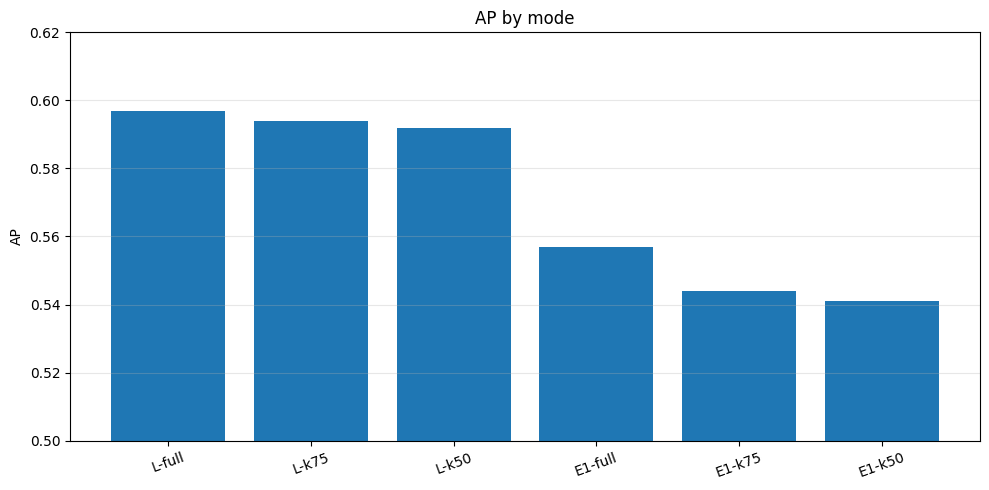

/home/semyon/Загрузки/rtdetr_cpu_project/outputs/plots/ap_by_mode.png


In [69]:
plots_dir = ROOT / "outputs" / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

plot_df = final_table.copy()

order = ["L-full", "L-k75", "L-k50", "E1-full", "E1-k75", "E1-k50"]
plot_df["mode"] = pd.Categorical(plot_df["mode"], categories=order, ordered=True)
plot_df = plot_df.sort_values("mode")

plt.figure(figsize=(10, 5))
plt.bar(plot_df["mode"].astype(str), plot_df["AP"])
plt.ylabel("AP")
plt.title("AP by mode")
plt.xticks(rotation=20)
plt.ylim(0.50, 0.62)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

path1 = plots_dir / "ap_by_mode.png"
plt.savefig(path1, dpi=200, bbox_inches="tight")
plt.show()

print(path1)

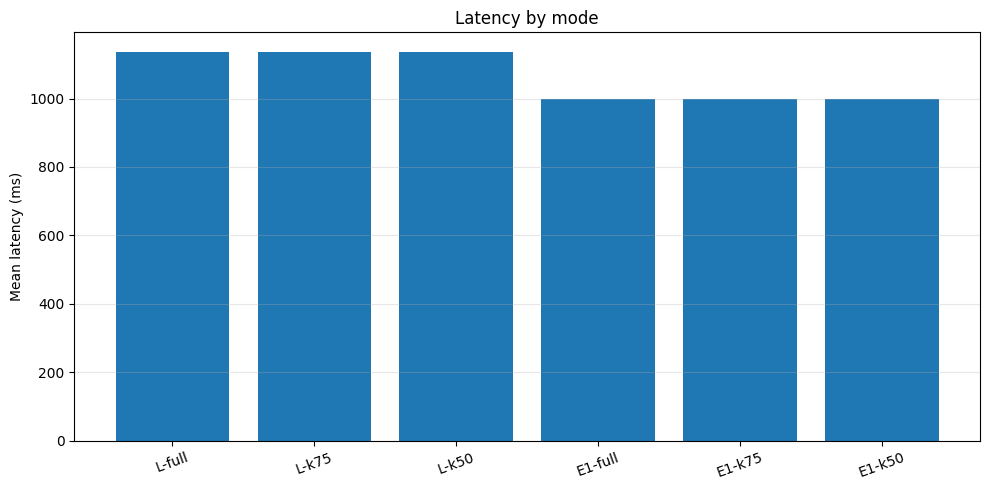

/home/semyon/Загрузки/rtdetr_cpu_project/outputs/plots/latency_by_mode.png


In [77]:
plot_df = final_table.copy()

order = ["L-full", "L-k75", "L-k50", "E1-full", "E1-k75", "E1-k50"]
plot_df["mode"] = pd.Categorical(plot_df["mode"], categories=order, ordered=True)
plot_df = plot_df.sort_values("mode")

plt.figure(figsize=(10, 5))
plt.bar(plot_df["mode"].astype(str), plot_df["mean_latency_ms"])
plt.ylabel("Mean latency (ms)")
plt.title("Latency by mode")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

path2 = plots_dir / "latency_by_mode.png"
plt.savefig(path2, dpi=200, bbox_inches="tight")
plt.show()

print(path2)

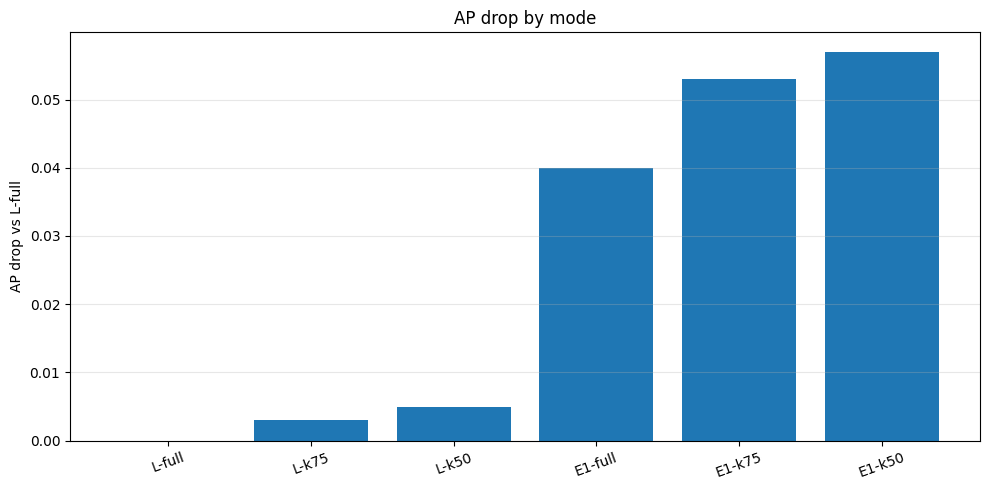

/home/semyon/Загрузки/rtdetr_cpu_project/outputs/plots/ap_drop_by_mode.png


In [78]:
plt.figure(figsize=(10, 5))
plt.bar(plot_df["mode"].astype(str), plot_df["AP_drop_vs_Lfull"])
plt.ylabel("AP drop vs L-full")
plt.title("AP drop by mode")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

path3 = plots_dir / "ap_drop_by_mode.png"
plt.savefig(path3, dpi=200, bbox_inches="tight")
plt.show()

print(path3)